In [ ]:
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.vgg16 import preprocess_input

In [40]:
train_dir = Path("/kaggle/input/pharaohs-300-augmented/augmented_train_300")
valid_dir = Path("/kaggle/input/pharaohs-300-augmented/validation_dataset_300")
test_dir = Path("/kaggle/input/pharaohs-300-augmented/test_dataset_300")

In [41]:
AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = 224
BATCH_SIZE = 32

In [42]:
IMG_EXTS = {".jpg"}  

def list_subdirs(path: Path):
    return sorted([p for p in path.iterdir() if p.is_dir()])

def make_df(root: Path):
    rows = []
    for class_dir in list_subdirs(root):
        label = class_dir.name
        for p in class_dir.iterdir():
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                rows.append({"label": label, "path": str(p)})
    return pd.DataFrame(rows, columns=["label", "path"])

def count_per_class(root: Path, classes):
    out = {}
    for c in classes:
        out[c] = sum(1 for p in (root / c).iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS)
    return out

In [43]:
train_df = make_df(train_dir)
val_df   = make_df(valid_dir)
test_df  = make_df(test_dir)

print("Train df:", train_df.shape)
print("Val df  :", val_df.shape)
print("Test df :", test_df.shape)

Train df: (20210, 2)
Val df  : (1395, 2)
Test df : (599, 2)


In [ ]:
classes = sorted(train_df["label"].unique().tolist())
print("Number of classes:", len(classes))
print("Sample classes:", classes[:10])

# sanity  same class set in val/test
print("Val classes match train:",  set(val_df["label"].unique()) == set(classes))
print("Test classes match train:", set(test_df["label"].unique()) == set(classes))

Number of classes: 96
Sample classes: ['Achoris', 'Ahmose_I', 'Akhenaton', 'Alexander_the_Great', 'Amasis_II', 'Amenemhat_I', 'Amenemhat_III', 'Amenhotep_II', 'Amenhotep_III', 'Amenhotep_III_and_God_Re-Horakhty']
Val classes match train: True
Test classes match train: True


In [45]:
train_counts = count_per_class(train_dir, classes)
val_counts   = count_per_class(valid_dir, classes)

train_vals = np.array([train_counts[c] for c in classes])
val_vals   = np.array([val_counts[c] for c in classes])

print("Train min/max:", train_vals.min(), train_vals.max(),
      "\nratio:", train_vals.max() / max(1, train_vals.min()))
print("Val   min/max:", val_vals.min(), val_vals.max())

Train min/max: 144 300 
ratio: 2.0833333333333335
Val   min/max: 4 42


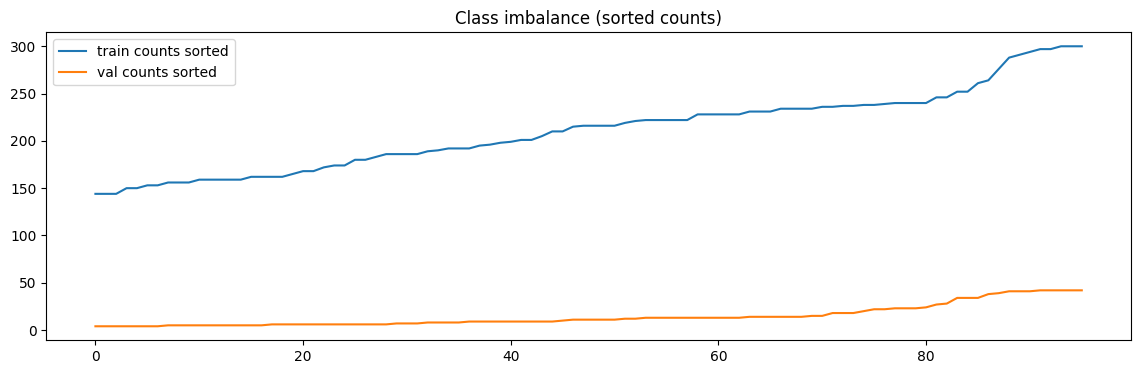

In [46]:
plt.figure(figsize=(14,4))
plt.plot(sorted(train_vals), label="train counts sorted")
plt.plot(sorted(val_vals), label="val counts sorted")
plt.legend()
plt.title("Class imbalance (sorted counts)")
plt.show()

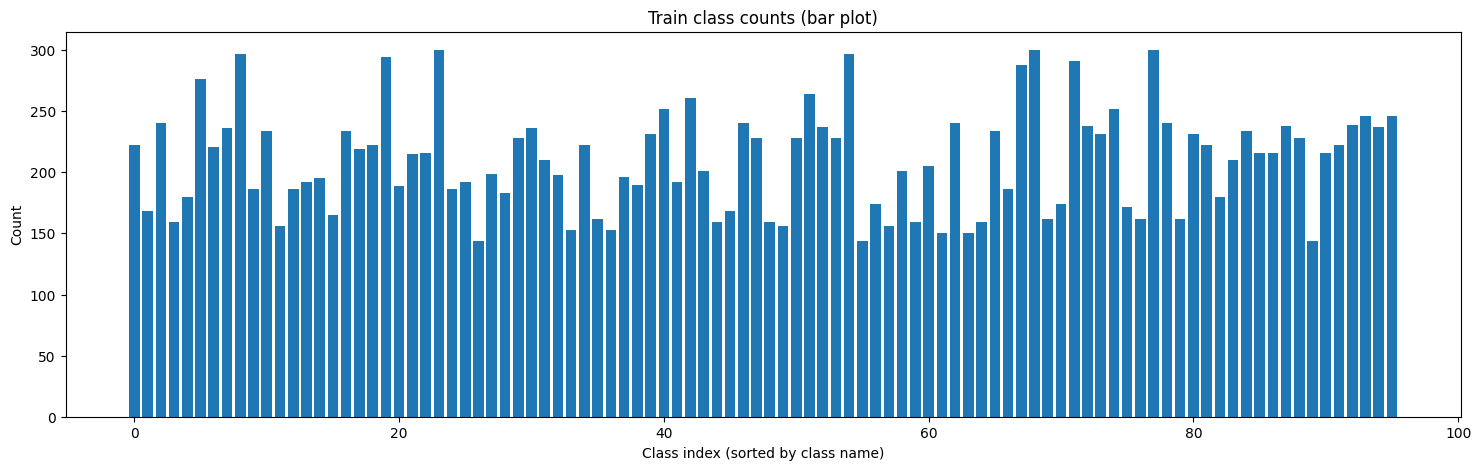

In [47]:
plt.figure(figsize=(18, 5))
plt.bar(range(len(classes)), train_vals)
plt.title("Train class counts (bar plot)")
plt.xlabel("Class index (sorted by class name)")
plt.ylabel("Count")
plt.show()

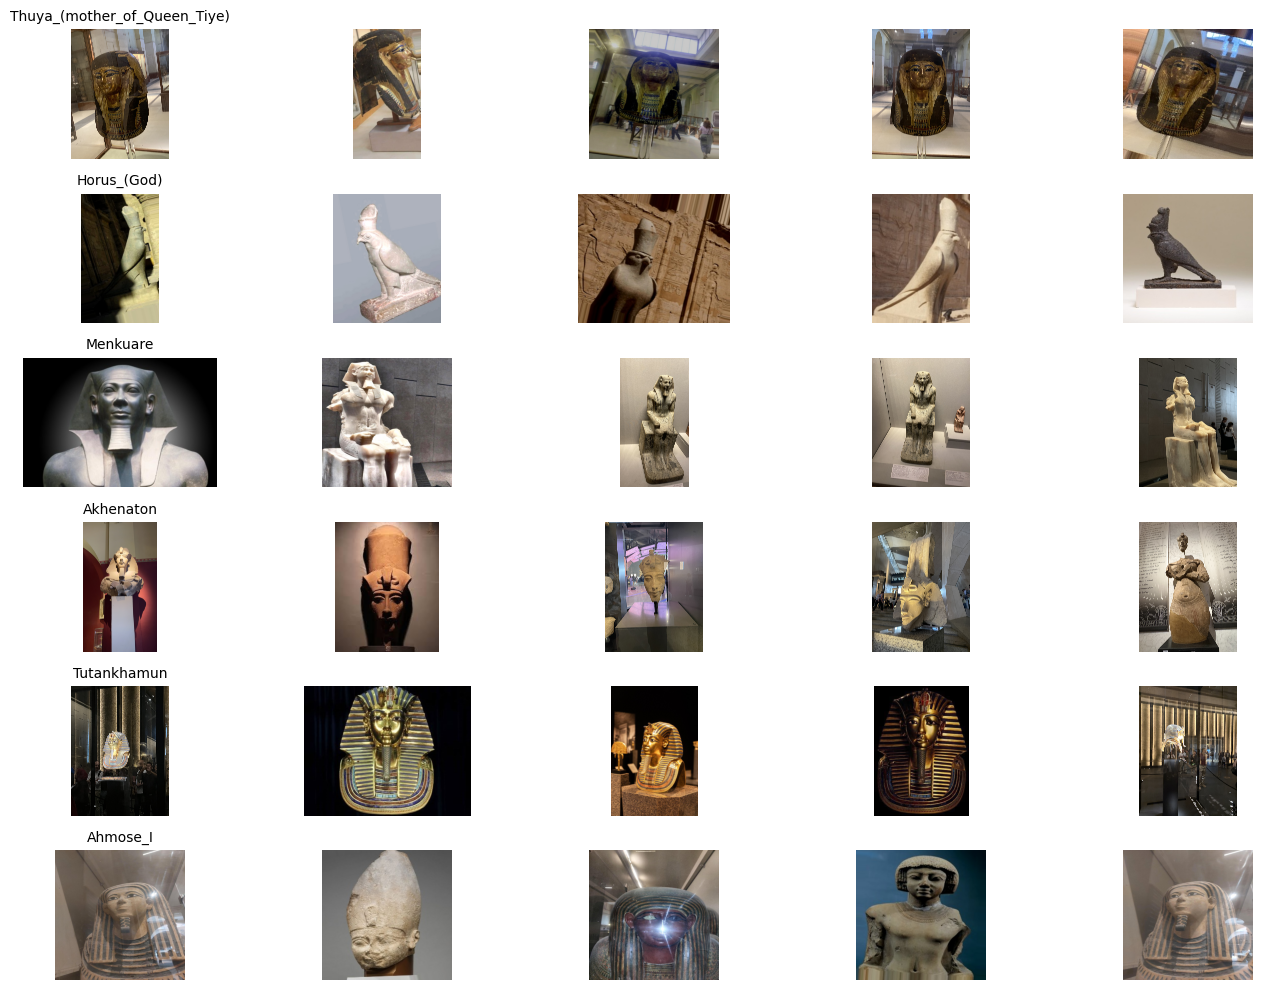

In [48]:
def show_samples_per_class(root: Path, class_names, k=5, rows=6):
    plt.figure(figsize=(14, 10))
    shown = 0
    picked = random.sample(class_names, min(len(class_names), rows))

    for cls in picked:
        imgs = [p for p in (root/cls).iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]
        if not imgs:
            continue
        for i in range(min(k, len(imgs))):
            img_path = str(random.choice(imgs))
            img = tf.keras.utils.load_img(img_path)
            ax = plt.subplot(rows, k, shown + 1)
            plt.imshow(img)
            plt.axis("off")
            if i == 0:
                ax.set_title(cls, fontsize=10)
            shown += 1
            if shown >= rows * k:
                break
        if shown >= rows * k:
            break

    plt.tight_layout()
    plt.show()

show_samples_per_class(train_dir, classes, k=5, rows=6)

In [49]:
encoder = LabelEncoder()

train_df["label_enc"] = encoder.fit_transform(train_df["label"])
val_df["label_enc"]   = encoder.transform(val_df["label"])
test_df["label_enc"]  = encoder.transform(test_df["label"])

NUM_CLASSES = len(encoder.classes_)
print("NUM_CLASSES:", NUM_CLASSES)

NUM_CLASSES: 96


In [50]:
y_train = train_df["label_enc"].values
classes_int = np.unique(y_train)

cw = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes_int,
    y=y_train)
cw

array([0.94829204, 1.2531002 , 0.87717014, 1.3240304 , 1.16956019,
       0.76275664, 0.95258296, 0.89203743, 0.70882435, 1.13183244,
       0.89966168, 1.34949252, 1.13183244, 1.09646267, 1.07959402,
       1.27588384, 0.89966168, 0.96128234, 0.94829204, 0.71605726,
       1.11386684, 0.97916667, 0.97463349, 0.70173611, 1.13183244,
       1.09646267, 1.46195023, 1.05789363, 1.15038707, 0.92333699,
       0.89203743, 1.00248016, 1.06323653, 1.37595316, 0.94829204,
       1.29951132, 1.37595316, 1.07408588, 1.10800439, 0.9113456 ,
       0.83540013, 1.09646267, 0.80659323, 1.04736733, 1.3240304 ,
       1.2531002 , 0.87717014, 0.92333699, 1.3240304 , 1.34949252,
       0.92333699, 0.7974274 , 0.88827356, 0.92333699, 0.70882435,
       1.46195023, 1.20988985, 1.34949252, 1.04736733, 1.3240304 ,
       1.02693089, 1.40347222, 0.87717014, 1.40347222, 1.3240304 ,
       0.89966168, 1.13183244, 0.73097512, 0.70173611, 1.29951132,
       1.20988985, 0.72343929, 0.88454132, 0.9113456 , 0.83540

In [51]:
cw_dict = {int(c): float(w) for c, w in zip(classes_int, cw)}
cw_dict

{0: 0.9482920420420421,
 1: 1.2531001984126984,
 2: 0.8771701388888888,
 3: 1.3240303983228512,
 4: 1.1695601851851851,
 5: 0.7627566425120773,
 6: 0.9525829562594268,
 7: 0.892037429378531,
 8: 0.708824354657688,
 9: 1.1318324372759856,
 10: 0.8996616809116809,
 11: 1.3494925213675213,
 12: 1.1318324372759856,
 13: 1.0964626736111112,
 14: 1.079594017094017,
 15: 1.2758838383838385,
 16: 0.8996616809116809,
 17: 0.9612823439878234,
 18: 0.9482920420420421,
 19: 0.7160572562358276,
 20: 1.1138668430335097,
 21: 0.9791666666666666,
 22: 0.974633487654321,
 23: 0.7017361111111111,
 24: 1.1318324372759856,
 25: 1.0964626736111112,
 26: 1.4619502314814814,
 27: 1.057893634840871,
 28: 1.150387067395264,
 29: 0.9233369883040936,
 30: 0.892037429378531,
 31: 1.0024801587301588,
 32: 1.063236531986532,
 33: 1.3759531590413943,
 34: 0.9482920420420421,
 35: 1.299511316872428,
 36: 1.3759531590413943,
 37: 1.0740858843537415,
 38: 1.1080043859649122,
 39: 0.9113455988455988,
 40: 0.835400132275

In [52]:
cw_vec = np.zeros(NUM_CLASSES, dtype=np.float32)
for c, w in cw_dict.items():
    cw_vec[int(c)] = float(w)

cw_tf = tf.constant(cw_vec, dtype=tf.float32)
print("Example weights:", list(cw_dict.items())[:10])

Example weights: [(0, 0.9482920420420421), (1, 1.2531001984126984), (2, 0.8771701388888888), (3, 1.3240303983228512), (4, 1.1695601851851851), (5, 0.7627566425120773), (6, 0.9525829562594268), (7, 0.892037429378531), (8, 0.708824354657688), (9, 1.1318324372759856)]


In [53]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03, fill_mode="reflect"),
    layers.RandomZoom(0.08),
    layers.RandomBrightness(0.08),
    layers.RandomContrast(0.1),
], name="data_aug")

In [ ]:
class TFDataset:
    def __init__(self, df, batch_size=BATCH_SIZE, shuffle=True, image_size=IMG_SIZE, augment=False):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.image_size = image_size if isinstance(image_size, int) else image_size[0]
        self.dataset = self._build_dataset()

    def _load_raw(self, path, label):
        img = tf.io.read_file(path)        
        img = tf.image.decode_jpeg(img, channels=3)  
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, (self.image_size, self.image_size), method="bilinear")  
        img = preprocess_input(img)
        img = tf.cast(img, tf.float32)  
        label = tf.cast(label, tf.int32)  
        return img, label

    def _build_dataset(self):
        paths = self.df["path"].values
        labels = self.df["label_enc"].values.astype(np.int32)

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        ds = ds.map(self._load_raw, num_parallel_calls=AUTOTUNE)

        if self.shuffle:
            ds = ds.shuffle(buffer_size= min(len(self.df), 5000), reshuffle_each_iteration=True)

        if self.augment:
            ds = ds.map(lambda x, y: (data_aug(x, training=True), y),num_parallel_calls=AUTOTUNE)

        ds = ds.batch(self.batch_size)
        
        return ds

    def __iter__(self):
        return iter(self.dataset)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))


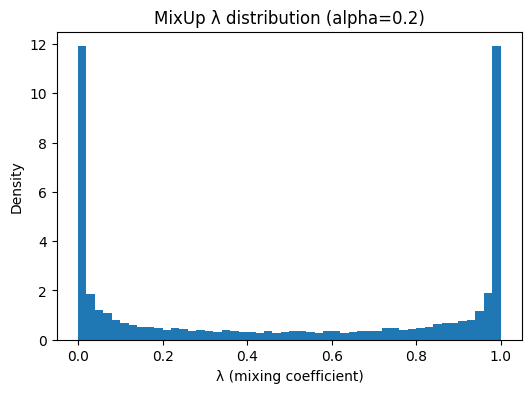

In [ ]:
alpha = 0.2
N = 10000

lam = np.random.beta(alpha, alpha, N)

plt.figure(figsize=(6,4))
plt.hist(lam, bins=50, density=True)
plt.xlabel("λ (mixing coefficient)")
plt.ylabel("Density")
plt.title(f"MixUp λ distribution (alpha={alpha})")
plt.show()

In [ ]:
MIXUP_ALPHA = 0.2

def _sample_beta(alpha, shape):
    g1 = tf.random.gamma(shape, alpha)
    g2 = tf.random.gamma(shape, alpha)
    return g1 / (g1 + g2)

def _to_onehot(labels_int):
    return tf.one_hot(labels_int, NUM_CLASSES, dtype=tf.float32)

def _sample_weight_from_onehot(y_onehot):
    return tf.reduce_sum(y_onehot * cw_tf[None, :], axis=1)  


In [22]:
def mixup_batch(images, labels_int):
    B = tf.shape(images)[0]
    y1 = _to_onehot(labels_int)

    idx = tf.random.shuffle(tf.range(B))
    x2 = tf.gather(images, idx)
    y2 = tf.gather(y1, idx)

    lam = _sample_beta(MIXUP_ALPHA, [B])
    lam_x = tf.reshape(lam, [B, 1, 1, 1])
    lam_y = tf.reshape(lam, [B, 1])

    x = images * lam_x + x2 * (1.0 - lam_x)
    y = y1 * lam_y + y2 * (1.0 - lam_y)

    sw = _sample_weight_from_onehot(y)
    return x, y, sw

In [ ]:
def plain_batch_train(images, labels_int):
    y = _to_onehot(labels_int)
    sw = _sample_weight_from_onehot(y)
    return images, y, sw

def plain_batch_eval(images, labels_int):
    y = _to_onehot(labels_int)
    sw = tf.ones([tf.shape(images)[0]], tf.float32)
    return images, y, sw

def maybe_mixup(images, labels_int, mixup_prob):
    mixup_prob = tf.cast(mixup_prob, tf.float32)
    do = tf.random.uniform([]) < mixup_prob
    return tf.cond(
        do,
        lambda: mixup_batch(images, labels_int),
        lambda: plain_batch_train(images, labels_int),
    )

In [24]:
def apply_aug(x, y):
    return data_aug(x, training=True), y

In [ ]:
base_ds = TFDataset(train_df, augment=False, shuffle=True).dataset

# Phase A: NO MixUp (prob = 0)
train_ds = (
    base_ds
    .map(apply_aug, num_parallel_calls=AUTOTUNE)
    .map(plain_batch_train, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)  
)

# Phase B: MixUp ON (light)
MIXUP_PROB  = 0.25
train_ds_mix = (
    base_ds
    .map(apply_aug, num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: maybe_mixup(x, y, MIXUP_PROB), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)


# Val/Test: no MixUp, no class-weight sample weights (keep eval setting)
val_ds = (
    TFDataset(val_df, augment=False, shuffle=False).dataset
    .map(plain_batch_eval, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    TFDataset(test_df, augment=False, shuffle=False).dataset
    .map(plain_batch_eval, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)


In [23]:
#Sanity Check

# Phase A batch
x, y, sw = next(iter(train_ds.take(1)))
print("train_ds:", x.shape, y.shape, sw.shape, y.dtype, sw.dtype)

# Phase B batch
x2, y2, sw2 = next(iter(train_ds_mix.take(1)))
print("train_ds_mix:", x2.shape, y2.shape, sw2.shape, y2.dtype, sw2.dtype)

# Validation batch
xv, yv, swv = next(iter(val_ds.take(1)))
print("val_ds:", xv.shape, yv.shape, swv.shape, yv.dtype, swv.dtype)

train_ds: (32, 224, 224, 3) (32, 96) (32,) <dtype: 'float32'> <dtype: 'float32'>
train_ds_mix: (32, 224, 224, 3) (32, 96) (32,) <dtype: 'float32'> <dtype: 'float32'>
val_ds: (32, 224, 224, 3) (32, 96) (32,) <dtype: 'float32'> <dtype: 'float32'>


In [26]:
base = tf.keras.applications.VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling=None
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [27]:
def build_model(base,img_size=IMG_SIZE):
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training = False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(inputs, outputs)
    
    return model

In [28]:
base.trainable = False
model = build_model(base, IMG_SIZE)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │        12,384 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,894,880 (56.82 MB)

 Trainable params: 178,400 (696.88 KB)

 Non-trainable params: 14,716,480 (56.14 MB)

In [29]:
print(train_ds.element_spec)
print(val_ds.element_spec)
print(test_ds.element_spec)

(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))


In [30]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=3e-5, weight_decay=1e-4), 
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0),
    metrics=["categorical_accuracy"]
)

ckpt = ModelCheckpoint(
    "vgg16_best.keras",
    monitor="val_categorical_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

early = EarlyStopping(
    monitor="val_categorical_accuracy",
    patience=5,
    mode="max",
    restore_best_weights=True,
    verbose=1,
)

In [31]:
history1 = model.fit(
    train_ds,                   
    validation_data=val_ds,
    epochs=15,
    callbacks=[ckpt, early],
    verbose=1
)

Epoch 1/15


I0000 00:00:1770139868.002340     124 service.cc:152] XLA service 0x7bc208117920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770139868.002387     124 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770139868.997381     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/632 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - categorical_accuracy: 0.0156 - loss: 5.4693         

I0000 00:00:1770139880.649892     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - categorical_accuracy: 0.0140 - loss: 5.2589
Epoch 1: val_categorical_accuracy improved from -inf to 0.03226, saving model to convnext_small_best.keras
632/632 ━━━━━━━━━━━━━━━━━━━━ 606s 741ms/step - categorical_accuracy: 0.0140 - loss: 5.2587 - val_categorical_accuracy: 0.0323 - val_loss: 6.1714
Epoch 2/15
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - categorical_accuracy: 0.0293 - loss: 4.8081
Epoch 2: val_categorical_accuracy improved from 0.03226 to 0.06452, saving model to convnext_small_best.keras
632/632 ━━━━━━━━━━━━━━━━━━━━ 563s 708ms/step - categorical_accuracy: 0.0293 - loss: 4.8080 - val_categorical_accuracy: 0.0645 - val_loss: 5.6099
Epoch 3/15
631/632 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - categorical_accuracy: 0.0559 - loss: 4.4877
Epoch 3: val_categorical_accuracy improved from 0.06452 to 0.09749, saving model to convnext_small_best.keras
632/632 ━━━━━━━━━━━━━━━━━━━━ 567s 713ms/step - categorical_accuracy: 0.0560 - loss: 4.4874 - v

In [32]:
model.save("/kaggle/working/vgg16_pharaohs300_headonly.keras")

In [54]:
UNFREEZE_LAST_N = int( len(base.layers) * 0.35) 
print("Total layers:", len(base.layers))
print("Unfreezing last:", UNFREEZE_LAST_N)

Total layers: 19
Unfreezing last: 6


In [55]:
base.trainable = True

# freeze all but last N layers 
for layer in base.layers[:-UNFREEZE_LAST_N]:
    layer.trainable = False

# keep BatchNorm frozen
for layer in base.layers[-UNFREEZE_LAST_N:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

In [56]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1.5e-5, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0),
    metrics=["categorical_accuracy"]
)
ckpt2 = ModelCheckpoint(
    "vgg16_stage2_best.keras",
    monitor="val_categorical_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

In [57]:
history2 = model.fit(
    train_ds_mix,
    validation_data=val_ds,
    epochs=25,
    callbacks=[ckpt2, early],
    verbose = 1
)

Epoch 1/25
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - categorical_accuracy: 0.4757 - loss: 2.4360
Epoch 1: val_categorical_accuracy improved from -inf to 0.41147, saving model to vgg16_stage2_best.keras
632/632 ━━━━━━━━━━━━━━━━━━━━ 599s 776ms/step - categorical_accuracy: 0.4757 - loss: 2.4358 - val_categorical_accuracy: 0.4115 - val_loss: 2.6576
Epoch 2/25
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - categorical_accuracy: 0.5492 - loss: 2.1157
Epoch 2: val_categorical_accuracy improved from 0.41147 to 0.49606, saving model to vgg16_stage2_best.keras
632/632 ━━━━━━━━━━━━━━━━━━━━ 671s 903ms/step - categorical_accuracy: 0.5492 - loss: 2.1156 - val_categorical_accuracy: 0.4961 - val_loss: 2.2248
Epoch 3/25
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - categorical_accuracy: 0.6144 - loss: 1.9023
Epoch 3: val_categorical_accuracy improved from 0.49606 to 0.50753, saving model to vgg16_stage2_best.keras
632/632 ━━━━━━━━━━━━━━━━━━━━ 638s 843ms/step - categorical_accuracy: 0.6144 - loss: 1.902

In [59]:
model.save("/kaggle/working/vgg16_pharaohs 300_base_mixup.keras")

In [ ]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)
test_loss, test_acc   = model.evaluate(test_ds, verbose=0)

print("Restored Train acc:", train_acc * 100)
print("Restored Val   acc:", val_acc * 100)
print("Restored Test  acc:", test_acc * 100)

Restored Train acc: 97.78822660446167
Restored Val   acc: 81.4336895942688
Restored Test  acc: 82.6377272605896


In [ ]:
y_true, y_pred = [], []

for xb, yb, swb in test_ds:
    preds = model.predict(xb, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

    y_true.extend(np.argmax(yb.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# accuracy
test_acc = (y_true == y_pred).mean()
print(f"Test accuracy: {test_acc:.8f}")

# report
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

cm_test = confusion_matrix(y_true, y_pred)
print("Confusion matrix shape:", cm_test.shape)
print("\nConfusion Matrix:\n", cm_test)